# Fig.12：严格联合分布与 Fig.19 顺序采样对照

沿用方案 A（每壳每时间片独立重抽）、Prada12-HMF、严格 Appendix D 联合分布、默认环境密度和速度，以及 Sesana K 的高偏心率端点约定。全局环境步长为 200 Myr；本次使用 `adaptive_log_a` 积分器修复原 Euler 轨道越界。原论文 2 Myr Euler 仍可通过 `integration_method='euler'` 调用。

两组结果都是未经人口重加权的累计原始事件数。小样本乘以 $2\times10^6/N$ 的结果只表示样本量换算后的期望估计；不是运行了论文的生产样本。后半部分单独调用 p_a_j.py 的 Fig.19 顺序采样器。详细诊断见 [各壳层pbhmerger结果诊断.md](../各壳层pbhmerger结果诊断.md)。

## 严格联合分布基线：初始时间片与原图参考

从 $z=12$ 开始演化。Fig.12 保留首片；文章“丢弃首片、从约 $z=10$ 展示”的陈述针对相邻时间片平均的并合率。

原始 PDF 矢量路径显示：图上 $t=0$ 已有首片累计值，最后一片标签为 13200 Myr，水平段延伸到 13400 Myr。本 notebook 将事件放在实际完成时间边界上；对照时把原图第一个计数放在 200 Myr，并同时保留数字化文件中的原始标签。

默认加载已执行并保存的结果。设置 `RUN_MONTE_CARLO=True` 可直接调用主驱动重算；更改参数后需要重算，缓存参数不一致会显式报错。

In [1]:
from dataclasses import asdict
import json
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'binary_single_montecarlo.py').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from binary_single import BinarySingleConfig
from binary_single_montecarlo import run_raw_shell_monte_carlo
from p_a_j import AppendixDOrbitalDistribution

OUTPUT = ROOT / 'pic_and_data' / 'fig12_diagnosis'
RUN_MONTE_CARLO = False
SAMPLES = 5_000
SEED = 20260922
CHUNK_SIZE = 5_000
config = BinarySingleConfig(
    halo_model='prada12_hmf_sigma',
    velocity_mu=0.5, ksi=1.0,
    global_timestep_myr=200.0,
    local_timestep_myr=2.0,  # only controls the legacy Euler branch
    start_redshift=12.0,
    sample_count_per_shell_and_step=SAMPLES,
    integration_method='adaptive_log_a',
    eccentricity_growth_model='sesana_endpoint',
    integration_rtol=1e-6,
    integration_time_atol_myr=1e-8,
    integration_log_j2_atol=1e-9,
    integration_max_log_a_step=0.25,
    merger_radius_gm_c2=6.0,
)
distribution = AppendixDOrbitalDistribution(pbh_mass_msun=30.0, f_pbh=1.0)
print(json.dumps(asdict(config), indent=2))
print('Initial rho_eq [Msun/pc^3]:', distribution.rho_eq_msun_pc3)


{
  "halo_model": "prada12_hmf_sigma",
  "primary_mass_msun": 30.0,
  "secondary_mass_msun": 30.0,
  "pbh_fraction_total": 1.0,
  "fraction_single": 0.5,
  "fraction_binary": 0.5,
  "velocity_mu": 0.5,
  "ksi": 1.0,
  "global_timestep_myr": 200.0,
  "local_timestep_myr": 2.0,
  "start_redshift": 12.0,
  "sample_count_per_shell_and_step": 5000,
  "integration_method": "adaptive_log_a",
  "eccentricity_growth_model": "sesana_endpoint",
  "integration_rtol": 1e-06,
  "integration_time_atol_myr": 1e-08,
  "integration_log_j2_atol": 1e-09,
  "integration_max_log_a_step": 0.25,
  "integration_max_attempts": 10000,
  "merger_radius_gm_c2": 6.0
}
Initial rho_eq [Msun/pc^3]: 1614.9730832622506


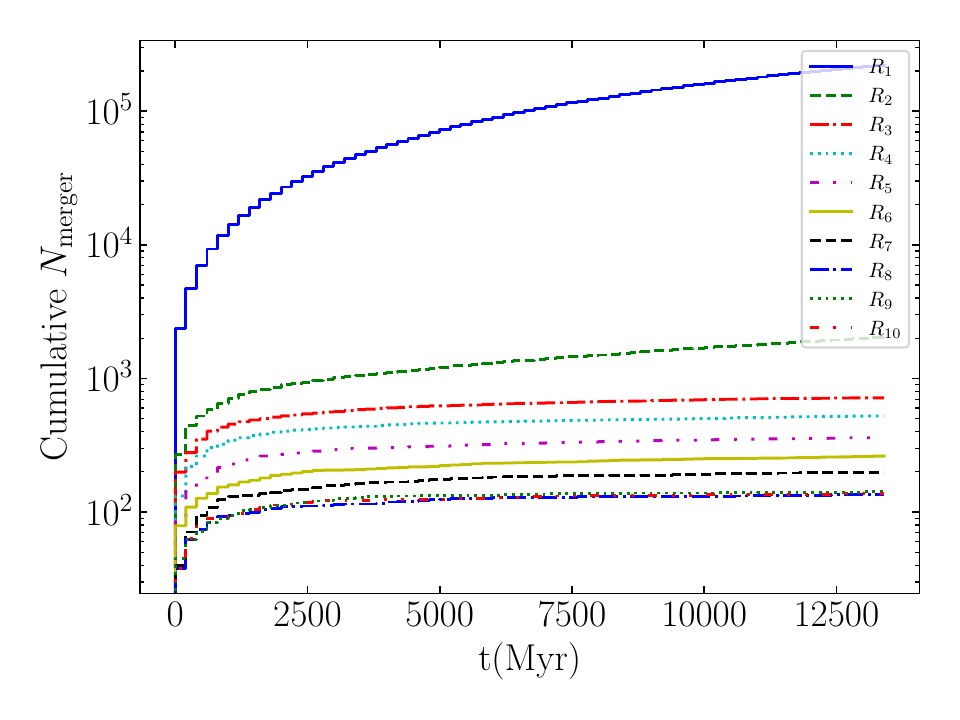

In [2]:
display(Image(filename=str(ROOT / 'pic_and_data' / 'fig12_paper_reference.png')))


In [3]:
if RUN_MONTE_CARLO:
    result = run_raw_shell_monte_carlo(
        present_day_halo_mass_msun=1.15e12, config=config,
        orbital_distribution=distribution, random_seed=SEED,
        chunk_size=CHUNK_SIZE,
        progress_callback=lambda i, n: print(f'{i}/{n}') if i % 10 == 0 or i == n else None,
    )
    data = dict(
        time=result.elapsed_time_edges_myr, redshift=result.redshift_edges,
        sampled=result.sampled_per_step, hard=result.hard_per_step,
        merged=result.mergers_per_step, invalid=result.invalid_per_step,
        k_above=result.k_above_calibration_per_step, cumulative=result.cumulative_mergers,
    )
else:
    metadata = json.loads((OUTPUT / 'strict_config.json').read_text(encoding='utf-8'))
    if (metadata['config'] != asdict(config) or metadata['prior'] != asdict(distribution)
            or metadata['seed'] != SEED or metadata['chunk_size'] != CHUNK_SIZE):
        raise ValueError('Cached parameters differ; set RUN_MONTE_CARLO=True.')
    data = dict(np.load(OUTPUT / 'strict.npz'))

print('Samples:', int(data['sampled'].sum()), 'hard:', int(data['hard'].sum()))
print('Merged:', int(data['merged'].sum()), 'invalid:', int(data['invalid'].sum()))
print('Endpoint by shell:', data['cumulative'][-1].tolist())
print('K above tabulated e range:', int(data['k_above'].sum()))
if np.any(data['invalid']):
    raise RuntimeError('Numerical failures remain; do not interpret these counts as converged.')

OUTPUT.mkdir(exist_ok=True)
np.savetxt(OUTPUT / 'notebook_cumulative.csv',
           np.column_stack((data['time'], data['redshift'], data['cumulative'])),
           delimiter=',', header='t_myr,z,' + ','.join(f'R{i}' for i in range(1, 11)), comments='')
(OUTPUT / 'notebook_config.json').write_text(json.dumps({
    'config': asdict(config), 'prior': asdict(distribution),
    'seed': SEED, 'chunk_size': CHUNK_SIZE, 'loaded_cache': not RUN_MONTE_CARLO,
}, indent=2), encoding='utf-8')


Samples: 3400000 hard: 415033
Merged: 235307 invalid: 0
Endpoint by shell: [148409, 37650, 19140, 14756, 7988, 3698, 1575, 836, 589, 666]
K above tabulated e range: 373997


1043

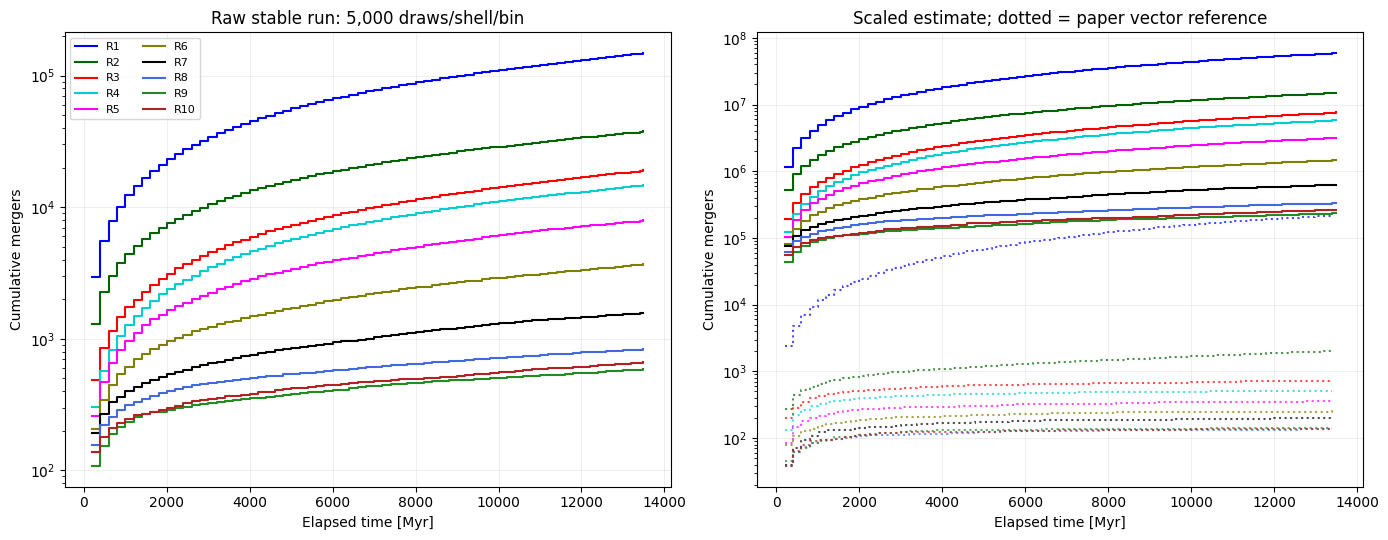

| Shell | Raw count | Estimate at 2 million draws | Paper endpoint | Ratio |
|---|---:|---:|---:|---:|
| R1 | 148,409 | 59,363,600 | 219,397 | 270.6 |
| R2 | 37,650 | 15,060,000 | 2,010 | 7492.5 |
| R3 | 19,140 | 7,656,000 | 711 | 10767.9 |
| R4 | 14,756 | 5,902,400 | 506 | 11664.8 |
| R5 | 7,988 | 3,195,200 | 360 | 8875.6 |
| R6 | 3,698 | 1,479,200 | 262 | 5645.8 |
| R7 | 1,575 | 630,000 | 198 | 3181.8 |
| R8 | 836 | 334,400 | 135 | 2477.0 |
| R9 | 589 | 235,600 | 142 | 1659.2 |
| R10 | 666 | 266,400 | 138 | 1930.4 |

| Shell | Paper start point | Run first bin / 5,000 | Estimate at 2 million +/- MCSE | Estimate / paper |
|---|---:|---:|---:|---:|
| R1 | 2,377 | 2,930 | 1,172,000 +/- 13,933 | 493.1 |
| R2 | 268 | 1,301 | 520,400 +/- 12,411 | 1,941.8 |
| R3 | 199 | 485 | 194,000 +/- 8,372 | 974.9 |
| R4 | 132 | 302 | 120,800 +/- 6,739 | 915.2 |
| R5 | 85 | 260 | 104,000 +/- 6,281 | 1,223.5 |
| R6 | 79 | 205 | 82,000 +/- 5,609 | 1,038.0 |
| R7 | 40 | 192 | 76,800 +/- 5,436 | 1,920.0 |
| R8 | 38 | 155 | 62,000 +/- 4,903 | 1,631.6 |
| R9 | 45 | 108 | 43,200 +/- 4,112 | 960.0 |
| R10 | 38 | 138 | 55,200 +/- 4,634 | 1,452.6 |

The paper t=0 point represents the first cumulative time bin; it is compared with this run first z=12 to 200 Myr bin. MCSE is the pilot binomial error scaled by 400, not the uncertainty from an actual two million sample run.

In [4]:
reference = np.genfromtxt(OUTPUT / 'paper_reference.csv', delimiter=',', names=True)
colors = ['blue', 'darkgreen', 'red', 'darkturquoise', 'magenta',
          'olive', 'black', 'royalblue', 'forestgreen', 'firebrick']
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
scale = 2_000_000 / SAMPLES
for i, color in enumerate(colors):
    raw = data['cumulative'][:, i]
    axes[0].step(data['time'], np.where(raw > 0, raw, np.nan),
                 where='post', color=color, label=f'R{i+1}')
    axes[1].step(data['time'], np.where(raw > 0, raw * scale, np.nan),
                 where='post', color=color)
    axes[1].step(reference['t_completed_if_first_bin_at_zero_myr'], reference[f'R{i+1}'],
                 where='post', color=color, linestyle=':', alpha=0.7)
for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('Elapsed time [Myr]')
    ax.set_ylabel('Cumulative mergers')
    ax.grid(alpha=0.2)
axes[0].set_title(f'Raw stable run: {SAMPLES:,} draws/shell/bin')
axes[0].legend(ncol=2, fontsize=8)
axes[1].set_title('Scaled estimate; dotted = paper vector reference')
fig.tight_layout()
fig.savefig(OUTPUT / 'fig12_adaptive_notebook.png', dpi=180)
plt.show()

lines = ['| Shell | Raw count | Estimate at 2 million draws | Paper endpoint | Ratio |',
         '|---|---:|---:|---:|---:|']
for i in range(10):
    raw = int(data['cumulative'][-1, i])
    paper = reference[f'R{i+1}'][-1]
    lines.append(f'| R{i+1} | {raw:,} | {raw*scale:,.0f} | {paper:,.0f} | {raw*scale/paper:.1f} |')
display(Markdown('\n'.join(lines)))

first_reference = np.genfromtxt(OUTPUT / 'paper_reference.csv', delimiter=',', names=True, max_rows=1)
initial_lines = ['| Shell | Paper start point | Run first bin / 5,000 | Estimate at 2 million +/- MCSE | Estimate / paper |',
                 '|---|---:|---:|---:|---:|']
for i in range(10):
    raw = int(data['merged'][0, i])
    paper = int(np.rint(first_reference[f'R{i+1}']))
    estimate = raw * scale
    mcse = np.sqrt(raw * (1 - raw / SAMPLES) * SAMPLES / (SAMPLES - 1)) * scale
    initial_lines.append(f'| R{i+1} | {paper:,} | {raw:,} | {estimate:,.0f} +/- {mcse:,.0f} | {estimate/paper:,.1f} |')
display(Markdown('\n'.join(initial_lines)))
display(Markdown('The paper t=0 point represents the first cumulative time bin; it is compared with this run first z=12 to 200 Myr bin. MCSE is the pilot binomial error scaled by 400, not the uncertainty from an actual two million sample run.'))


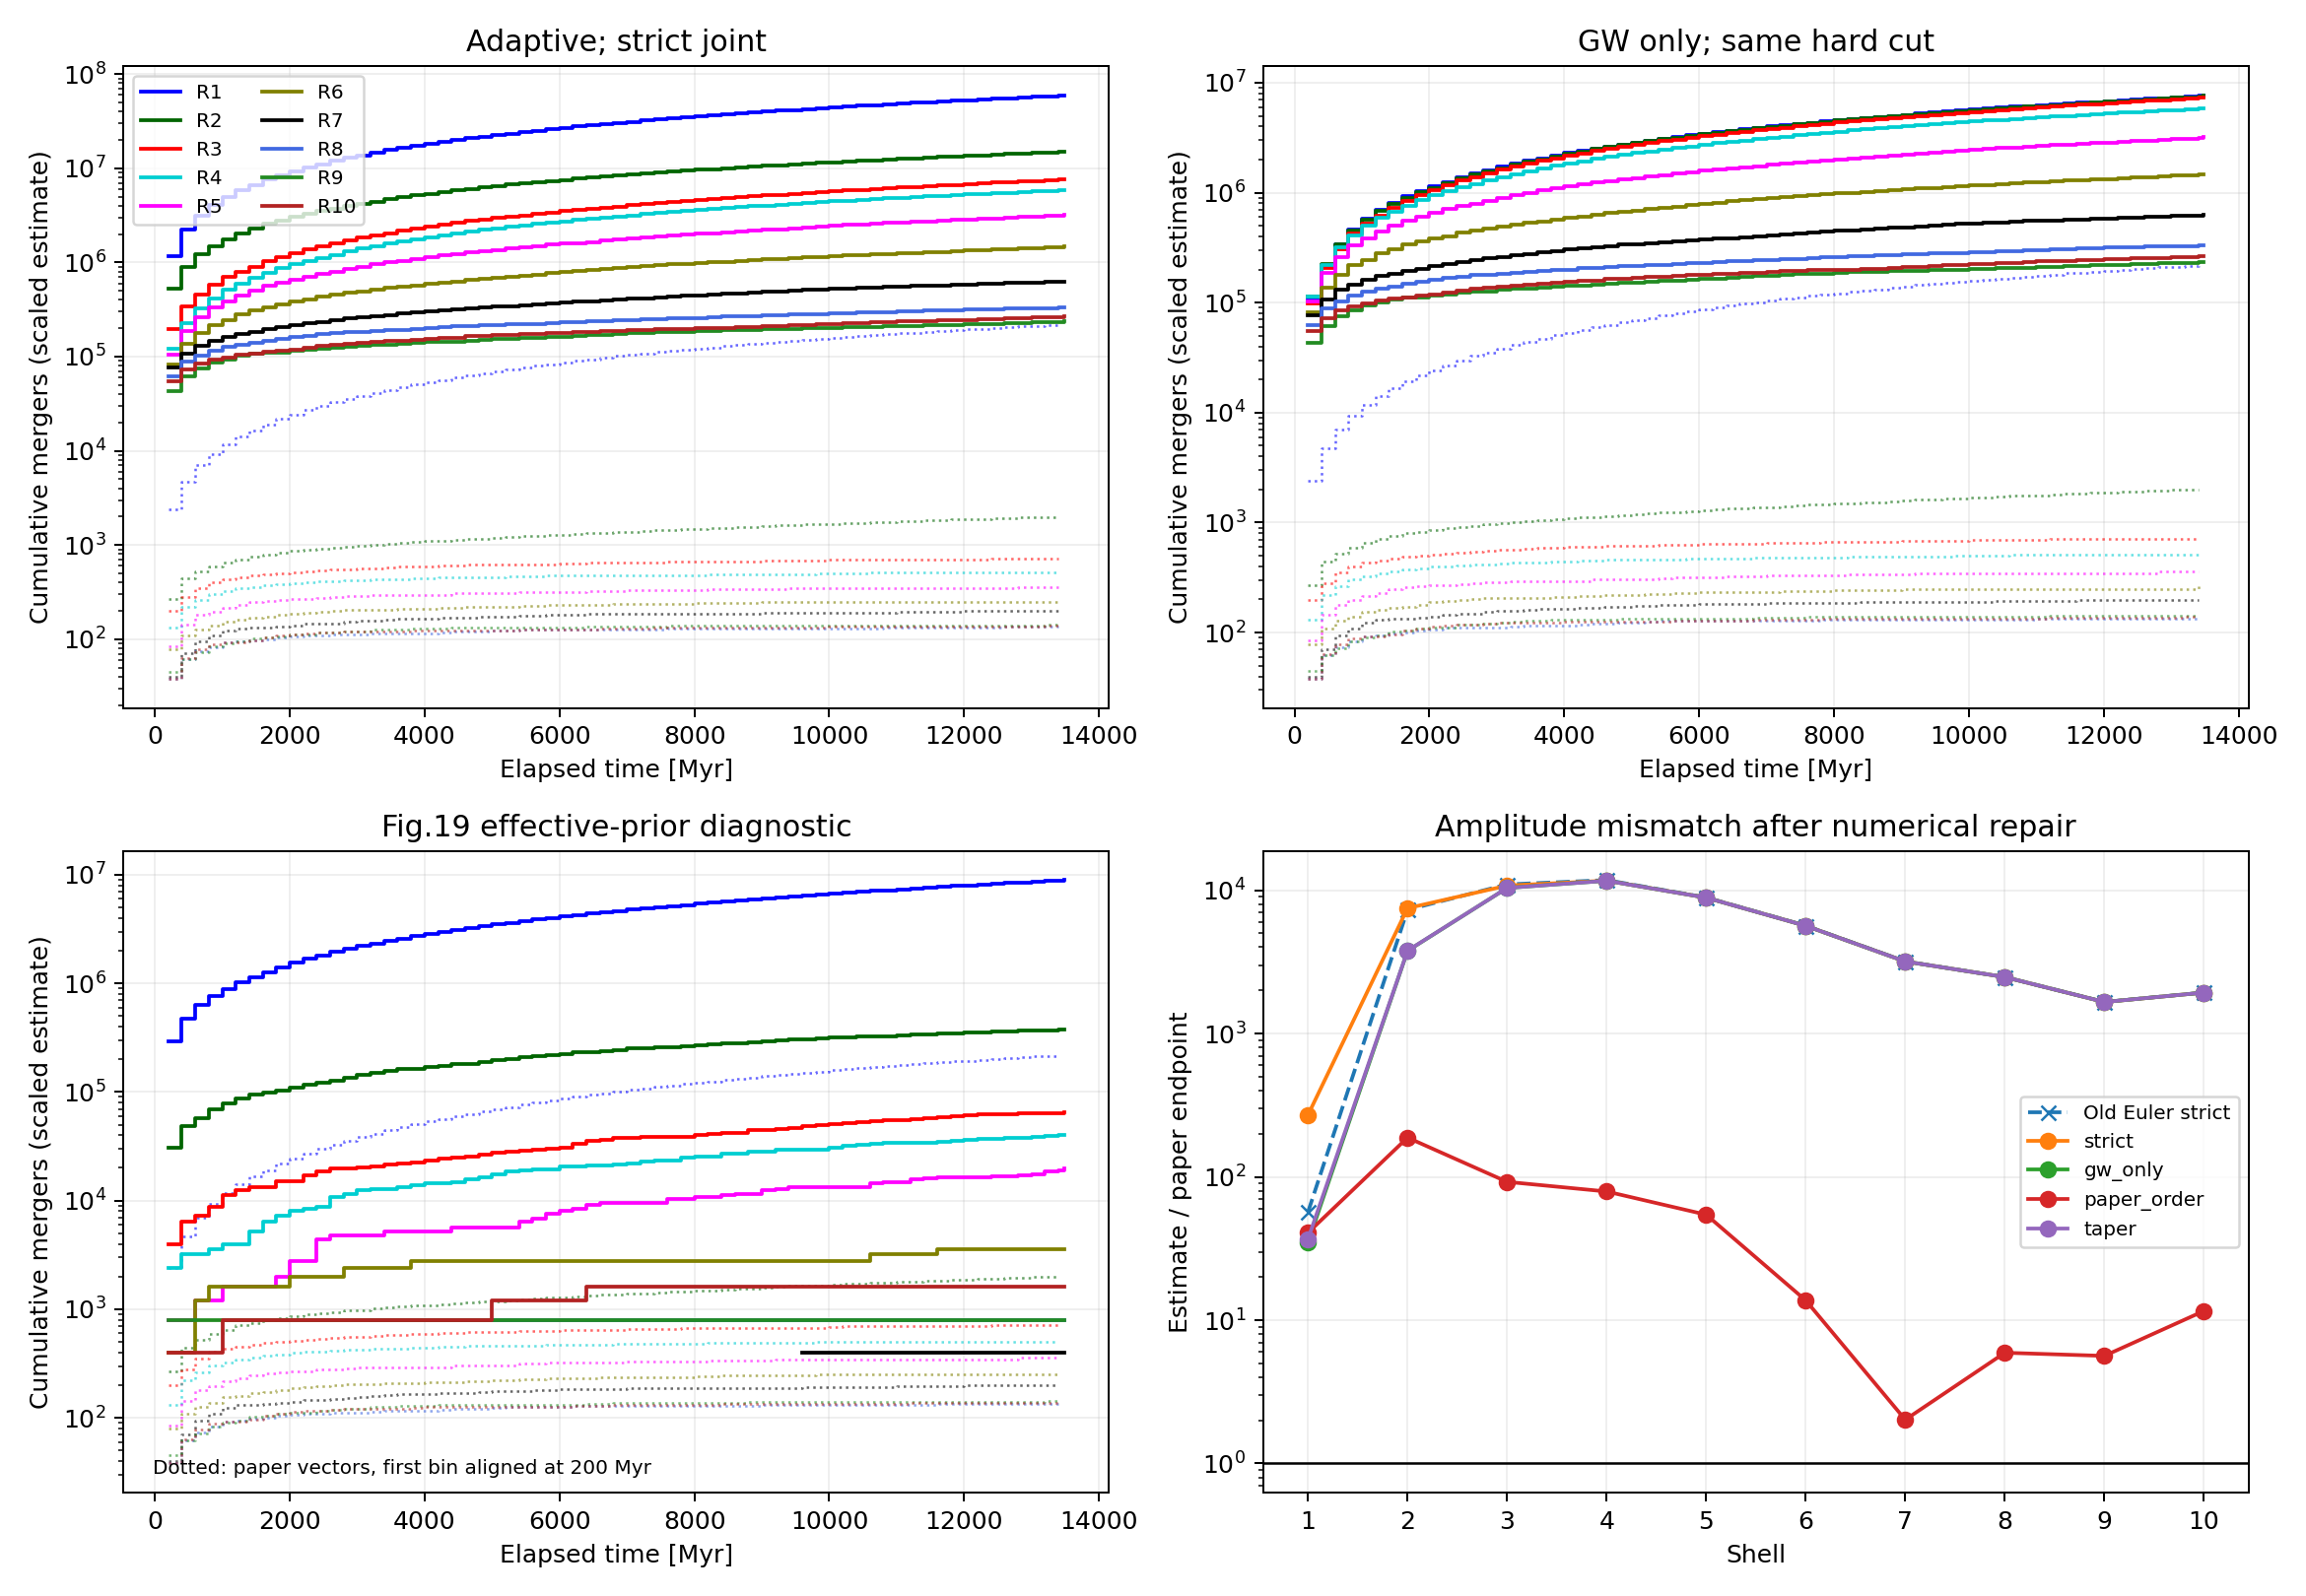

integration_summary.json
{
  "chain_rule_max_relative_error": 8.95032407976521e-11,
  "dop853_orbits": 71,
  "dop853_success": true,
  "dop853_classification_differences": 0,
  "dop853_max_time_error_myr": 0.0025714625847399475,
  "dop853_max_survivor_a_relative_error": 1.719718811798998e-08,
  "circular_merger_time_myr": 100.00002128963285,
  "circular_expected_merger_time_myr": 100.0,
  "circular_survivor_a_relative_error": 8.577252241792621e-10,
  "circular_invalid": 0
}
full_history_convergence.json
{
  "max_bin_count_difference": 1,
  "number_of_changed_bins": 1,
  "final_count_difference": [
    0,
    1,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0
  ]
}


In [5]:
comparison = OUTPUT / 'fig12_diagnostic_comparison.png'
if comparison.exists():
    display(Image(filename=str(comparison)))
for filename in ['integration_summary.json', 'full_history_convergence.json']:
    path = OUTPUT / filename
    if path.exists():
        print(filename)
        print(path.read_text(encoding='utf-8'))


## 结果解释

自适应积分修复了内壳大量 $e>1$ 越界，恢复了当前主设置下 $R_1$ 的主导地位。它采用相同的 Eqs.(19)/(25)，以 $u=\ln(a_0/a)$ 为独立变量，演化 $t$ 与 $\ln(1-e^2)$；每条轨道独立控制误差。$a=6G(m_1+m_2)/c^2$ 是本项目明确给出的终止半径，已经和 3、60 倍半径对照。它不是论文原始 Euler 算法的隐式修改。

当前严格联合分布、Prada12-HMF 和高偏心率 K 端点规则仍与论文图的生成约定存在差异。积分收敛不等于 Fig.12 幅度复现。GW-only 对照保持同一个初始硬双星筛选；其计数用于量化原初高偏心率双星自身的 GW 并合背景，不能直接当作另一个可相加的物理通道。

Fig.19 有效先验、K 的高偏心率衰减、Ludlow16、速度评价半径等结果均在诊断报告中标明。没有用任意壳层缩放系数贴合原图。人口重加权、HMF 积分与 cohort 继承不属于此 notebook。

## 按 Fig.19 正文顺序重新运行 Fig.12

Appendix D 对 Fig.19 的描述是先抽取 $0<j<1$，再从 $P(a,j)$ 抽取 $10^{-6}<a<1$ pc。下方通过 p_a_j.sample_figure19_orbital_parameters 生成逐项对应的 $(a,j,e)$，交给同一 Monte Carlo 驱动层。原文没有公开第一步所需的尺度；这里沿用 p_a_j.py 中由 Fig.19 反推的两个有效尺度，不把它们当成唯一的理论预测。

仅替换初始轨道采样器。halo、环境、K、时间片、稳定积分器和每壳每片 5,000 个样本保持上面的设置。论文 Fig.12 使用 Ludlow16；本轮保留此前指定的 Prada12-HMF，借此测量采样顺序替换的影响。RUN_PAPER_ORDER_MONTE_CARLO=True 会实际重算并保存独立缓存；False 会核对参数后读取缓存。原图每壳每片为 2,000,000 个样本，图中的 400 倍换算是估计值。

In [6]:
import p_a_j as orbital_prior

class Figure19PaperOrderDistribution:
    def sample(self, n, rng):
        return orbital_prior.sample_figure19_orbital_parameters(
            n, rng,
            sigma_eq=orbital_prior.DEFAULT_SIGMA_EQ,
            minimum_semi_major_axis_pc=1.0e-6,
            maximum_semi_major_axis_pc=1.0,
            angular_momentum_scale_for_sampling=orbital_prior.FIGURE19_EFFECTIVE_ANGULAR_MOMENTUM_SCALE,
            semi_major_axis_scale_pc=orbital_prior.FIGURE19_EFFECTIVE_SEMIMAJOR_AXIS_SCALE_PC,
        )

RUN_PAPER_ORDER_MONTE_CARLO = True
paper_distribution = Figure19PaperOrderDistribution()
paper_prior_settings = {
    'sampler': 'p_a_j.sample_figure19_orbital_parameters',
    'order': 'j_then_a_given_j',
    'sigma_eq': orbital_prior.DEFAULT_SIGMA_EQ,
    'minimum_semi_major_axis_pc': 1.0e-6,
    'maximum_semi_major_axis_pc': 1.0,
    'j_scale': orbital_prior.FIGURE19_EFFECTIVE_ANGULAR_MOMENTUM_SCALE,
    'a_scale_pc': orbital_prior.FIGURE19_EFFECTIVE_SEMIMAJOR_AXIS_SCALE_PC,
}
paper_metadata = {
    'config': asdict(config),
    'halo_M0_msun': 1.15e12,
    'prior': paper_prior_settings,
    'seed': SEED,
    'chunk_size': CHUNK_SIZE,
    'scheme': 'A independent redraw',
}
paper_cache = OUTPUT / 'fig12_paper_order_notebook.npz'
paper_config_path = OUTPUT / 'fig12_paper_order_notebook_config.json'
if RUN_PAPER_ORDER_MONTE_CARLO:
    paper_result = run_raw_shell_monte_carlo(
        present_day_halo_mass_msun=paper_metadata['halo_M0_msun'],
        config=config,
        orbital_distribution=paper_distribution,
        random_seed=SEED,
        chunk_size=CHUNK_SIZE,
        progress_callback=lambda i, n: print(f'Fig.19 order: {i}/{n}') if i % 10 == 0 or i == n else None,
    )
    paper_data = dict(
        time=paper_result.elapsed_time_edges_myr,
        redshift=paper_result.redshift_edges,
        sampled=paper_result.sampled_per_step,
        hard=paper_result.hard_per_step,
        merged=paper_result.mergers_per_step,
        invalid=paper_result.invalid_per_step,
        k_above=paper_result.k_above_calibration_per_step,
        cumulative=paper_result.cumulative_mergers,
    )
    np.savez_compressed(paper_cache, **paper_data)
    paper_config_path.write_text(json.dumps(paper_metadata, indent=2), encoding='utf-8')
else:
    saved_metadata = json.loads(paper_config_path.read_text(encoding='utf-8'))
    if saved_metadata != paper_metadata:
        raise ValueError('Fig.19 order cache parameters differ; rerun Monte Carlo.')
    paper_data = dict(np.load(paper_cache))

print('Sampler:', paper_prior_settings)
print('Samples:', int(paper_data['sampled'].sum()), 'hard:', int(paper_data['hard'].sum()))
print('Merged:', int(paper_data['merged'].sum()), 'invalid:', int(paper_data['invalid'].sum()))
print('Endpoint by shell:', paper_data['cumulative'][-1].tolist())
if np.any(paper_data['invalid']):
    raise RuntimeError('Numerical failures remain in the Fig.19 order run.')


Fig.19 order: 10/68


Fig.19 order: 20/68


Fig.19 order: 30/68


Fig.19 order: 40/68


Fig.19 order: 50/68


Fig.19 order: 60/68


Fig.19 order: 68/68
Sampler: {'sampler': 'p_a_j.sample_figure19_orbital_parameters', 'order': 'j_then_a_given_j', 'sigma_eq': 0.005, 'minimum_semi_major_axis_pc': 1e-06, 'maximum_semi_major_axis_pc': 1.0, 'j_scale': 1.088798521872047, 'a_scale_pc': 0.034694}
Samples: 3400000 hard: 95992
Merged: 23625 invalid: 0
Endpoint by shell: [22350, 944, 164, 100, 49, 9, 1, 2, 2, 4]


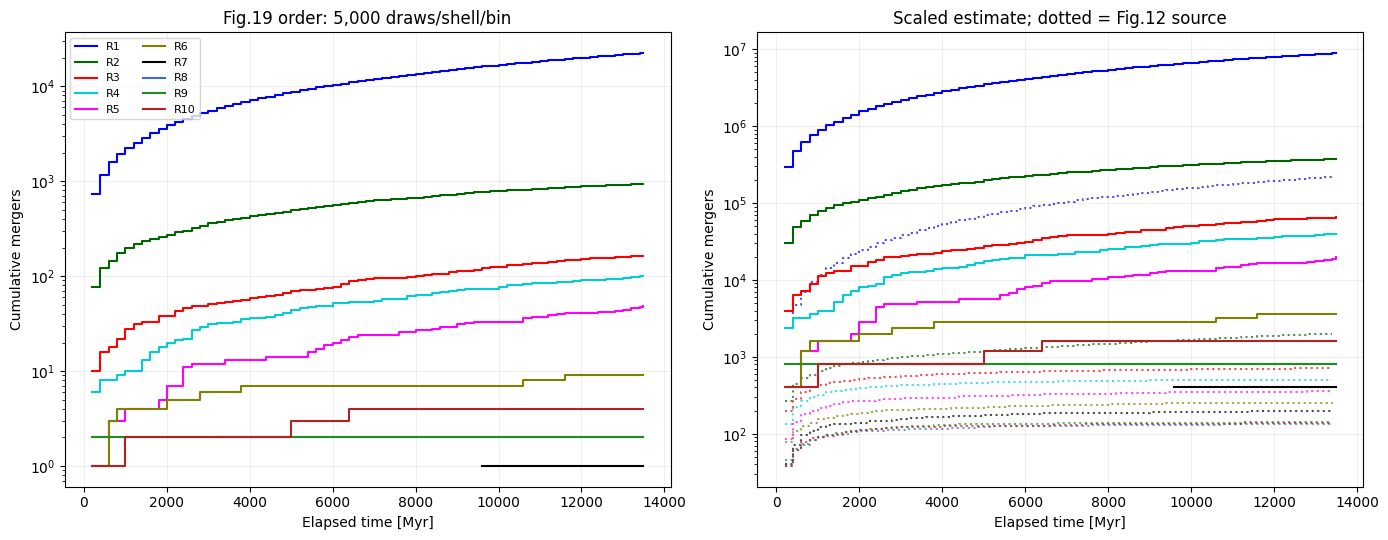

| Shell | Fig.12 first | Fig.19 order first / 5,000 | First scaled | Fig.12 endpoint | Fig.19 order endpoint / 5,000 | Endpoint scaled | Endpoint ratio |
|---|---:|---:|---:|---:|---:|---:|---:|
| R1 | 2,377 | 728 | 291,200 | 219,397 | 22,350 | 8,940,000 | 40.7 |
| R2 | 268 | 76 | 30,400 | 2,010 | 944 | 377,600 | 187.9 |
| R3 | 199 | 10 | 4,000 | 711 | 164 | 65,600 | 92.3 |
| R4 | 132 | 6 | 2,400 | 506 | 100 | 40,000 | 79.1 |
| R5 | 85 | 2 | 800 | 360 | 49 | 19,600 | 54.4 |
| R6 | 79 | 1 | 400 | 262 | 9 | 3,600 | 13.7 |
| R7 | 40 | 0 | 0 | 198 | 1 | 400 | 2.0 |
| R8 | 38 | 0 | 0 | 135 | 2 | 800 | 5.9 |
| R9 | 45 | 2 | 800 | 142 | 2 | 800 | 5.6 |
| R10 | 38 | 1 | 400 | 138 | 4 | 1,600 | 11.6 |

The original t=0 point is the first completed bin; the run first bin ends at 200 Myr. Outer-shell raw counts are small, so their scaled estimates have substantial Monte Carlo uncertainty. The effective Fig.19 prior is inferred from Fig.19 and does not establish the authors unpublished implementation.

In [7]:
paper_scale = 2_000_000 / SAMPLES
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for i, color in enumerate(colors):
    raw = paper_data['cumulative'][:, i]
    axes[0].step(paper_data['time'], np.where(raw > 0, raw, np.nan),
                 where='post', color=color, label=f'R{i+1}')
    axes[1].step(paper_data['time'], np.where(raw > 0, raw * paper_scale, np.nan),
                 where='post', color=color)
    axes[1].step(reference['t_completed_if_first_bin_at_zero_myr'],
                 reference[f'R{i+1}'], where='post',
                 color=color, linestyle=':', alpha=0.7)
for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('Elapsed time [Myr]')
    ax.set_ylabel('Cumulative mergers')
    ax.grid(alpha=0.2)
axes[0].set_title(f'Fig.19 order: {SAMPLES:,} draws/shell/bin')
axes[0].legend(ncol=2, fontsize=8)
axes[1].set_title('Scaled estimate; dotted = Fig.12 source')
fig.tight_layout()
fig.savefig(OUTPUT / 'fig12_paper_order_notebook.png', dpi=180)
plt.show()

np.savetxt(OUTPUT / 'fig12_paper_order_notebook_cumulative.csv',
           np.column_stack((paper_data['time'], paper_data['redshift'], paper_data['cumulative'])),
           delimiter=',', header='t_myr,z,' + ','.join(f'R{i}' for i in range(1, 11)), comments='')

paper_lines = [
    '| Shell | Fig.12 first | Fig.19 order first / 5,000 | First scaled | Fig.12 endpoint | Fig.19 order endpoint / 5,000 | Endpoint scaled | Endpoint ratio |',
    '|---|---:|---:|---:|---:|---:|---:|---:|',
]
for i in range(10):
    source_first = int(np.rint(reference[f'R{i+1}'][0]))
    source_end = int(np.rint(reference[f'R{i+1}'][-1]))
    first = int(paper_data['merged'][0, i])
    end = int(paper_data['cumulative'][-1, i])
    paper_lines.append(
        f'| R{i+1} | {source_first:,} | {first:,} | {first*paper_scale:,.0f} | '
        f'{source_end:,} | {end:,} | {end*paper_scale:,.0f} | {end*paper_scale/source_end:,.1f} |'
    )
display(Markdown('\n'.join(paper_lines)))
display(Markdown('The original t=0 point is the first completed bin; the run first bin ends at 200 Myr. Outer-shell raw counts are small, so their scaled estimates have substantial Monte Carlo uncertainty. The effective Fig.19 prior is inferred from Fig.19 and does not establish the authors unpublished implementation.'))


采样顺序的依据：[Aljaf 与 Cholis，Appendix D 的 Fig.19 描述](https://arxiv.org/html/2408.06515)。论文 Fig.12 使用每壳每片 $2\times10^6$ 个双星；本 notebook 的估计值保留样本量换算和有限 Monte Carlo 噪声。